# ПРОГНОЗИРОВАНИЕ ПРОДАЖ И СРАВНЕНИЕ ГИПОТЕЗ
## Цель: Сравнение качества прогноза (RMSLE) для 4-х гипотез.

Исходные данные — продажи в магазинах Эквадора с 1.янв.2013 до 15.мрт.2016, цена на нефть и календарь праздников. Валидация проходит на данных с 1 по 15 марта 2016 с помощью метрики RMSLE.

Проверяем 4 гипотезы:
1. Наивный прогноз — продажи сегодня как 16 дней назад.
2. Машинное обучение учитывает закономерности рассчитанных признаков (lightgbm, catboost, xgboost).
3. Старые наблюдения снижают точность прогноза (прогноз без данных за 2013 год).
4. Поведение продаж товаров отличается. Поэтому нужно прогнозировать каждую группу отдельно. Стратегия: 
    - Для стабильных продаж используем регрессионный анализ.
    - Для нестабильных — сначала определяем, будет ли продажа сегодня, а затем применяем регрессию.
    - Для околонулевых продаж предполагаем, что их не будет.

In [2]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

# ==============================================================================
# КОНФИГУРАЦИЯ
# ==============================================================================
DATA_PATH = '/kaggle/input/competitions/store-sales-time-series-forecasting/'

# Даты для эксперимента
TRAIN_END_DATE = '2016-02-29'
TEST_START_DATE = '2016-03-01'
TEST_END_DATE = '2016-03-15'

## Подготовка данных — загрузка и кодирование признаков
Расчет метрики прогноза и подготовка данных вынесены в отдельную часть.

In [3]:
# ==============================================================================
# ФУНКЦИИ
# ==============================================================================

def rmsle(y_true, y_pred):
    """Расчет метрики RMSLE"""
    y_true = np.maximum(y_true, 0)
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

def prepare_data():
    """Подготовка данных"""
    print("Загрузка и подготовка данных...")
    
    # 1. Загрузка данных
    df = pd.read_csv(DATA_PATH + 'train.csv')
    holidays = pd.read_csv(DATA_PATH + 'holidays_events.csv')
    oil = pd.read_csv(DATA_PATH + 'oil.csv')
    stores = pd.read_csv(DATA_PATH + 'stores.csv')

    # 2. Преобразование дат
    df['date'] = pd.to_datetime(df['date'])
    oil['date'] = pd.to_datetime(oil['date'])
    holidays['date'] = pd.to_datetime(holidays['date'])

    # 3. Агрегация
    df = df.groupby(['store_nbr', 'family', 'date']).agg({
        'sales': 'sum', 
        'onpromotion': 'sum'
    }).reset_index()

    # 4. Полный индекс
    all_pairs = df[['store_nbr', 'family']].drop_duplicates()
    min_date = df['date'].min()
    max_date = pd.to_datetime('2017-08-15') 
    all_dates = pd.date_range(min_date, max_date, freq='D')
    
    full_index = pd.MultiIndex.from_product(
        [all_dates, all_pairs['store_nbr'].unique(), all_pairs['family'].unique()],
        names=['date', 'store_nbr', 'family']
    )
    data = pd.DataFrame(index=full_index).reset_index()

    # 5. Merge
    data = data.merge(df, on=['date', 'store_nbr', 'family'], how='left')
    data['sales'] = data['sales'].fillna(0).astype('float32')
    data['onpromotion'] = data['onpromotion'].fillna(0).astype('float32')
    data = data.merge(stores, on='store_nbr', how='left')
    
    # Нефть
    full_date_range = pd.date_range(data['date'].min(), data['date'].max(), freq='D')
    oil_complete = pd.DataFrame({'date': full_date_range}).merge(oil, on='date', how='left')
    oil_complete['dcoilwtico'] = oil_complete['dcoilwtico'].ffill().bfill()
    data = data.merge(oil_complete[['date', 'dcoilwtico']], on='date', how='left')
    data['dcoilwtico'] = data['dcoilwtico'].ffill().bfill().astype('float32')

    # Праздники
    holidays_processed = holidays.rename(columns={'type': 'holiday_type'})
    data = data.merge(holidays_processed[['date', 'holiday_type', 'locale']], on='date', how='left')
    data['holiday_type'] = data['holiday_type'].fillna('None')
    data['is_holiday'] = (data['holiday_type'] != 'None').astype('int8')

    # Время
    data['dow'] = data['date'].dt.dayofweek.astype('int8')
    data['month'] = data['date'].dt.month.astype('int8')
    data['day'] = data['date'].dt.day.astype('int8')
    data['is_weekend'] = (data['dow'] >= 5).astype('int8')
    data['is_payday'] = ((data['day'] == 15) | (data['date'].dt.is_month_end)).astype('int8')

    # Лаги и статистики
    data['sales'] = data['sales'].fillna(0)
    grp = data.groupby(['store_nbr', 'family'])
    
    for lag in [16, 30, 60, 365]:
        data[f'lag_{lag}'] = grp['sales'].shift(lag).fillna(0).astype('float32')
        
    for win in [7, 14, 30]:
        data[f'rmean_{win}'] = grp['sales'].shift(16).rolling(win, min_periods=1).mean().fillna(0).astype('float32')
        data[f'rstd_{win}'] = grp['sales'].shift(16).rolling(win, min_periods=1).std().fillna(0).astype('float32')

    data['trend'] = (grp['sales'].shift(16) - grp['sales'].shift(30)).fillna(0).astype('float32')
    data['promo_last'] = grp['onpromotion'].shift(16).fillna(0).astype('float32')
    data['promo_mean'] = grp['onpromotion'].shift(16).rolling(30, min_periods=1).mean().fillna(0).astype('float32')

    # Агрегаты
    data['is_train'] = (data['date'] <= pd.Timestamp(TRAIN_END_DATE)).astype('int8')
    
    store_avg = data[data['is_train'] == 1].groupby('store_nbr')['sales'].mean().reset_index()
    store_avg.columns = ['store_nbr', 'store_avg']
    data = data.merge(store_avg, on='store_nbr', how='left')
    
    family_avg = data[data['is_train'] == 1].groupby('family')['sales'].mean().reset_index()
    family_avg.columns = ['family', 'family_avg']
    data = data.merge(family_avg, on='family', how='left')

    data['sales_log'] = np.log1p(data['sales']).astype('float32')

    # Кодирование
    categorical_cols = ['family', 'city', 'state', 'type', 'cluster', 'holiday_type']
    label_encoders = {}
    for col in categorical_cols:
        if col in data.columns:
            le = LabelEncoder()
            data[col] = data[col].astype(str)
            data[col] = le.fit_transform(data[col]).astype('int32')
            label_encoders[col] = le

    return data

In [4]:
# ==============================================================================
# ОСНОВНОЙ БЛОК
# ==============================================================================

# 1. Подготовка
data = prepare_data()

# Фильтрация под эксперимент
df_exp = data[data['date'] <= TEST_END_DATE].copy()
df_exp = df_exp.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

mask_train = df_exp['date'] <= TRAIN_END_DATE
mask_test = (df_exp['date'] >= TEST_START_DATE) & (df_exp['date'] <= TEST_END_DATE)

train_df = df_exp[mask_train].copy()
test_df = df_exp[mask_test].copy()

feature_cols = [
    'store_nbr', 'family', 'onpromotion', 'city', 'state', 'type', 'cluster',
    'dcoilwtico', 'holiday_type', 'dow', 'month', 'day', 'is_weekend', 'is_payday',
    'lag_16', 'lag_30', 'lag_60', 'lag_365', 'rmean_7', 'rmean_14', 'rmean_30',
    'rstd_7', 'rstd_14', 'rstd_30', 'trend', 'promo_last', 'promo_mean',
    'store_avg', 'family_avg'
]

X_train = train_df[feature_cols].fillna(-999)
y_train = train_df['sales_log']
X_test = test_df[feature_cols].fillna(-999)
y_test = test_df['sales_log']

# Конфигурация моделей
models_config = {
    'LightGBM': LGBMRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbose=-1, n_jobs=-1, random_state=42),
    'CatBoost': CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1, verbose=0, thread_count=-1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbosity=0, n_jobs=-1, random_state=42)
}

results_summary = {}

Загрузка и подготовка данных...


Данные подготовлены к проверке гипотез.

## Проверка гипотез.

In [5]:
# ==============================================================================
# ГИПОТЕЗА 1: НАИВНЫЙ ПРОГНОЗ
# ==============================================================================
test_df['naive_pred_log'] = np.log1p(test_df['lag_16'])
score_naive = rmsle(np.expm1(y_test), np.expm1(test_df['naive_pred_log']))
results_summary['H1: Naive (Lag-16)'] = score_naive
print(f"H1 Naive RMSLE: {score_naive:.5f}")

# ==============================================================================
# ГИПОТЕЗА 2: ML (ВСЕ ДАННЫЕ)
# ==============================================================================
best_score_h2 = float('inf')
for name, model in models_config.items():
    model.fit(X_train, y_train)
    preds = np.maximum(np.expm1(model.predict(X_test)), 0)
    score = rmsle(np.expm1(y_test), preds)
    if score < best_score_h2:
        best_score_h2 = score

results_summary['H2: ML (Full Data)'] = best_score_h2
print(f"H2 ML Best RMSLE: {best_score_h2:.5f}")

# ==============================================================================
# ГИПОТЕЗА 3: ML (БЕЗ 2013 ГОДА)
# ==============================================================================
mask_train_no_2013 = (df_exp['date'] > '2013-12-31') & (df_exp['date'] <= TRAIN_END_DATE)
train_df_no_2013 = df_exp[mask_train_no_2013].copy()
X_train_h3 = train_df_no_2013[feature_cols].fillna(-999)
y_train_h3 = train_df_no_2013['sales_log']

best_score_h3 = float('inf')
for name, model in models_config.items():
    # Пересоздаем модель, чтобы не обучать на старых данных
    if name == 'LightGBM':
        m = LGBMRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbose=-1, n_jobs=-1, random_state=42)
    elif name == 'CatBoost':
        m = CatBoostRegressor(iterations=500, depth=6, learning_rate=0.1, verbose=0, thread_count=-1, random_state=42)
    else:
        m = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbosity=0, n_jobs=-1, random_state=42)
        
    m.fit(X_train_h3, y_train_h3)
    preds = np.maximum(np.expm1(m.predict(X_test)), 0)
    score = rmsle(np.expm1(y_test), preds)
    if score < best_score_h3:
        best_score_h3 = score

results_summary['H3: ML (No 2013)'] = best_score_h3
print(f"H3 ML (No 2013) RMSLE: {best_score_h3:.5f}")

# ==============================================================================
# ГИПОТЕЗА 4: АДАПТИВНЫЕ МОДЕЛИ
# ==============================================================================
# Расчет доли нулей
train_stats = train_df.groupby(['store_nbr', 'family']).agg({
    'sales': ['count', lambda x: (x == 0).sum()]
}).reset_index()
train_stats.columns = ['store_nbr', 'family', 'total_days', 'zero_days']
train_stats['zero_ratio'] = train_stats['zero_days'] / train_stats['total_days']

train_stats['series_type'] = pd.cut(
    train_stats['zero_ratio'],
    bins=[0, 0.3, 0.9, 1.0],
    labels=['stable', 'periodic', 'zero_heavy'],
    include_lowest=True
)

train_local = train_df.merge(train_stats[['store_nbr', 'family', 'series_type']], on=['store_nbr', 'family'], how='left')
test_local = test_df.merge(train_stats[['store_nbr', 'family', 'series_type']], on=['store_nbr', 'family'], how='left')

full_predictions = np.zeros(len(test_local))

for series_type in ['stable', 'periodic', 'zero_heavy']:
    train_mask = train_local['series_type'] == series_type
    test_mask = test_local['series_type'] == series_type
    
    if train_mask.sum() == 0 or test_mask.sum() == 0:
        continue
        
    tr_grp = train_local[train_mask]
    te_grp = test_local[test_mask]
    
    X_tr = tr_grp[feature_cols].fillna(-999)
    y_tr = tr_grp['sales_log']
    X_te = te_grp[feature_cols].fillna(-999)
    y_te = te_grp['sales_log']
    
    if series_type == 'stable':
        model = LGBMRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbose=-1, n_jobs=-1, random_state=42)
        model.fit(X_tr, y_tr)
        preds = np.maximum(np.expm1(model.predict(X_te)), 0)
        
    elif series_type == 'periodic':
        y_bin = (tr_grp['sales'] > 0).astype('int8')
        clf = LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, verbose=-1, n_jobs=-1, random_state=42)
        clf.fit(X_tr, y_bin)
        prob = clf.predict_proba(X_te)[:, 1]
        
        tr_pos = tr_grp[tr_grp['sales'] > 0]
        if len(tr_pos) > 0:
            reg = LGBMRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, verbose=-1, n_jobs=-1, random_state=42)
            reg.fit(tr_pos[feature_cols].fillna(-999), tr_pos['sales_log'])
            vol = np.maximum(np.expm1(reg.predict(X_te)), 0)
            preds = prob * vol
        else:
            preds = np.zeros(len(te_grp))
            
    elif series_type == 'zero_heavy':
        preds = np.zeros(len(te_grp))
    
    # Запись прогнозов по индексам
    for i, idx in enumerate(te_grp.index):
        full_predictions[test_local.index.get_loc(idx)] = preds[i]

score_h4 = rmsle(np.expm1(test_local['sales_log']), full_predictions)
results_summary['H4: Adaptive Models'] = score_h4
print(f"H4 Adaptive RMSLE: {score_h4:.5f}")

H1 Naive RMSLE: 0.74753
H2 ML Best RMSLE: 0.48475
H3 ML (No 2013) RMSLE: 0.47829
H4 Adaptive RMSLE: 0.44968


Прогнозы готовы, визуально сравним результаты.

## Визуализация качества прогноза.

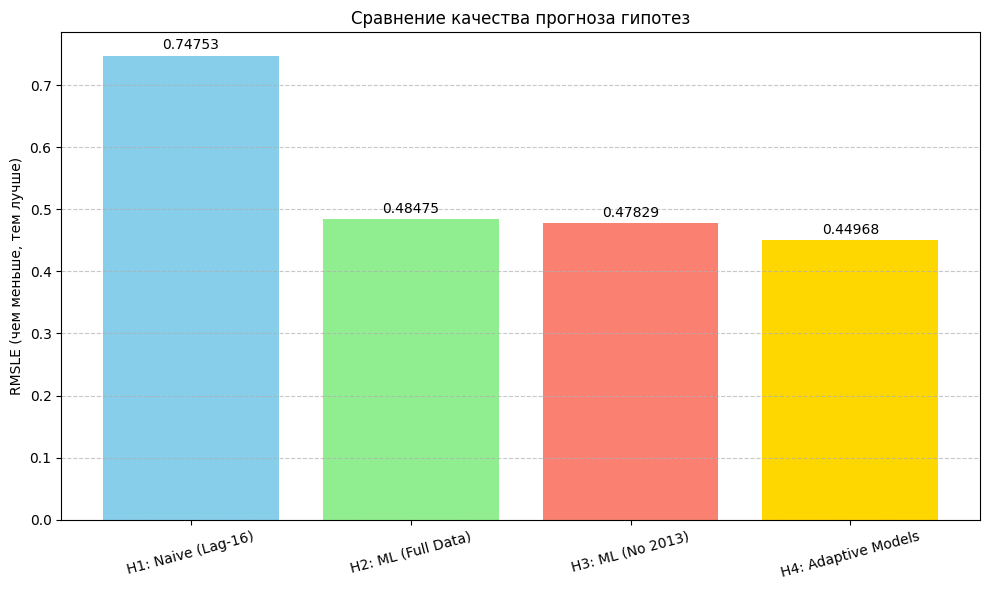


ЛУЧШАЯ ГИПОТЕЗА: H4: Adaptive Models
RMSLE: 0.44968


In [6]:
# ==============================================================================
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ==============================================================================
plt.figure(figsize=(10, 6))
plt.bar(results_summary.keys(), results_summary.values(), color=['skyblue', 'lightgreen', 'salmon', 'gold'])
plt.ylabel('RMSLE (чем меньше, тем лучше)')
plt.title('Сравнение качества прогноза гипотез')
plt.xticks(rotation=15)

# Добавление значений на столбцы
for i, v in enumerate(results_summary.values()):
    plt.text(i, v + 0.005, f'{v:.5f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Вывод лучшей гипотезы
best_hyp = min(results_summary, key=results_summary.get)
print("\n" + "="*40)
print(f"ЛУЧШАЯ ГИПОТЕЗА: {best_hyp}")
print(f"RMSLE: {results_summary[best_hyp]:.5f}")
print("="*40)

**Интерпретация результатов:**
* Самый большой скачок произошёл при переходе от наивной модели (H1) к лучшей ML‑модели (H2) — снижение RMSLE на 35,15%. Это говорит о том, что применение машинного обучения дало существенный прирост точности.
* Незначительное улучшение при исключении данных за 2013 год (H3): всего 1,33%. Вероятно, данные за 2013 год слабо влияли на качество прогноза либо содержали шум.
* Адаптивная модель (H4) показала дальнейшее улучшение (5,98% относительно H3), что подтверждает эффективность адаптивного подхода.

**Итоговый результат:** по сравнению с базовой наивной моделью ошибка RMSLE снизилась на почти 40% — это очень хороший показатель для прогнозной модели.